# MCLJES008 - P4 - Final Assignment 

## The choice of region for this assignment was the great barrier reef along the Australian coastline. This region was selected as much research has been conducted and confirmed that there is high seasonal variability in regards to chlorophyll concentrations in the area (Brodie et al., 2007). Furthermore, it is know that the Great Barrier reef is one of the most biodiverse and productive coastal areas in the world and thus, the projections and plots produced aimed to reflect this. In addition, it is argued that the shelves of the area contribute to creating temporal and spatial variations that can make monitoring chlorophyll concentrations more ardous than more standardised shelves (Brodie et al., 2007). Seeing as the chlorophyll dataset used to create the plots contained timeframs between 1997 and 1998, it allowed for comparisons with those from more recently collected data made available in other studies and demonstrates a rate of change. In addition this region was chose as it also assists in demonstrating the terestrial contributions made to chloropyll concentrations (Furnas et al., 2005; Brodie et al., 2007).

## Firstly, it should be noted that two datasets will be made use of in this assignment. For the bathymetry dataset, grid netCDF data will be downloaded from th Global Multi-Resolution Topography Data Synthesis (Ryan et al., 2009). This database produced grids collated together from scientists across the world from multi-beam sonar technologies (Ryan et al., 2009). This data comes in many resolutions and is particularly helpful for showcasing elevation as well as for selecting specific regions without being confined by standard shapefiles that may not have the points needed to produce the information sought out (Ryan et al., 2009). The next dataset used throughout the plots produced is that of Ocean Colour data. This dataset assists in displaying the variances observed in the ocean's colour from space (Sathyendranath et al. 2019).

### The first plot made was that of the bathymetry of the region selected; the Great Barrier Reef. The plot below aims to produce both topographical and elevation dynamics and makes use of a scale to demonstrate the elevation as well as depth. The plot produced displays depth in shades of blue while elevation is makes use of more green and brown shades to contrast. Further the landmass produced represents the nearest coastline included in the bathymetry grid. 

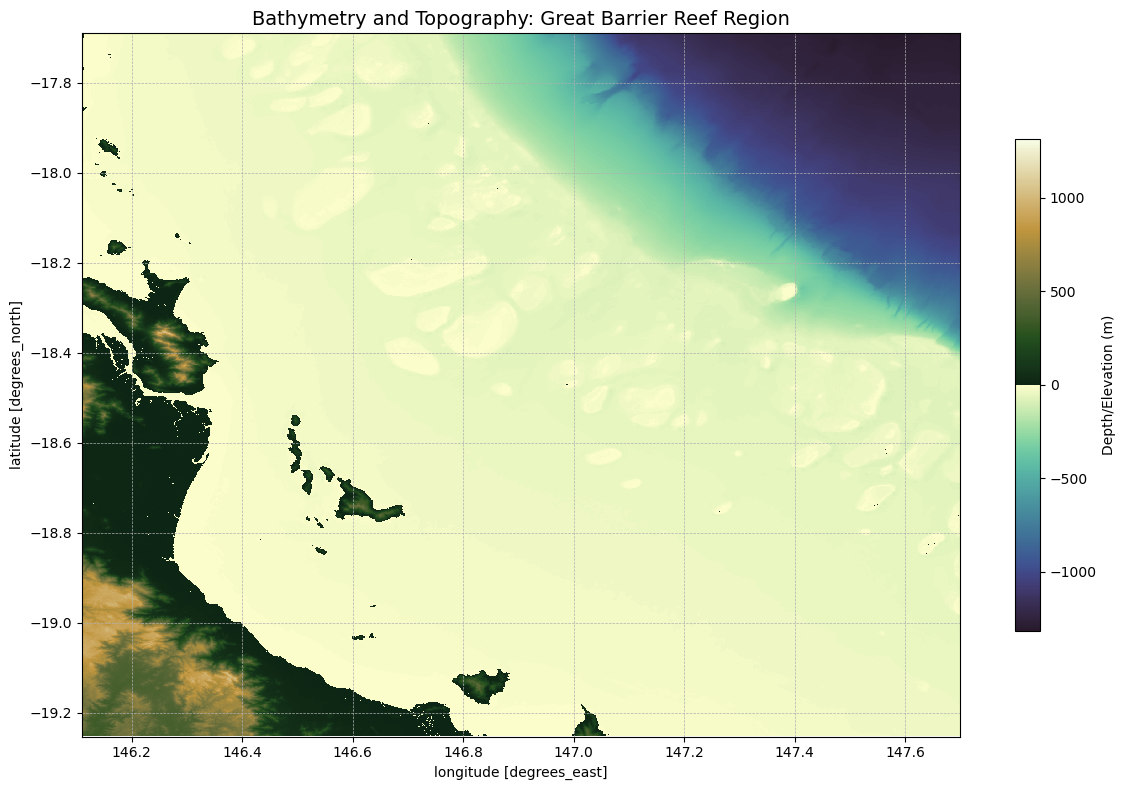

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

# Load bathymetry data
bathymetry = xr.open_dataset("C:/Users/jjmcl/OneDrive/Desktop/gbr100_10nov.grd")

lon_min, lon_max = 146.11, 147.7
lat_min, lat_max = -19.2525, -17.6906
bathymetry_subset = bathymetry.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

# Plot the bathymetry using the cmocean.cm.topo colormap
fig, ax = plt.subplots(figsize=(12, 8))


im = bathymetry_subset['z'].plot(
    ax=ax,
    cmap=cmocean.cm.topo,
    add_colorbar=True,
    cbar_kwargs={
        'label': 'Depth/Elevation (m)',
        'shrink': 0.7
    }
)


ax.set_title("Bathymetry and Topography: Great Barrier Reef Region", fontsize=14)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Add gridlines
ax.grid(True, linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()

### The next plot produced incorporates this bathymetry with a chlorophyll dataset retrieved from ESA-CCI Ocean Colour at a high resolution of 4km. Due to the size of this file processing of plots was very difficult and the alignment of the bathymetry and chlorophyll datasets was not precise in begining plotting. To combat this, several changes were made to the co-ordinates of the bathymetry to accomodate for the regional data available in the chlorophyll dataset. The colour map chosen was the cmocean.cm.algae colour map as this was determined to be the most appropriate to represent chlorophyll data. As suggested lognorm was also used to contrast the variations more clearly so observations can be made more easily. 

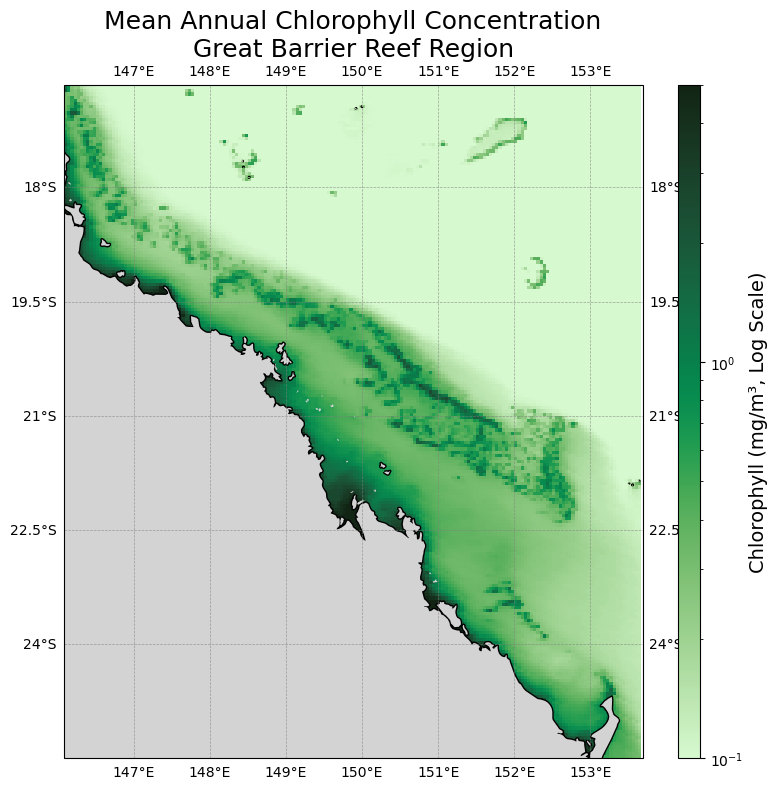

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

bathy = xr.open_dataset(r"C:/Users/jjmcl/OneDrive/Desktop/GMRTv4_3_0_20250329topo.grd")
chlor = xr.open_dataset(r"C:/Users/jjmcl/OneDrive/Desktop/P4/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

if chlor['lon'].max() > 180:
    chlor = chlor.assign_coords(lon=(((chlor['lon'] + 180) % 360) - 180))
chlor = chlor.sortby('lat')

true_lat, true_lon = int(bathy['dimension'][0]), int(bathy['dimension'][1])
y_min, y_max = float(bathy['y_range'][0]), float(bathy['y_range'][1])
x_min, x_max = float(bathy['x_range'][0]), float(bathy['x_range'][1])

lat_bathy = np.linspace(y_min, y_max, true_lat)
lon_bathy = np.linspace(x_min, x_max, true_lon)
z_bathy = bathy['z'].values.reshape((true_lat, true_lon))

buffer = 2.0  
chlor_subset = chlor.sel(
    lat=slice(y_min - buffer, y_max + buffer),
    lon=slice(x_min - buffer, x_max + buffer)
)


mean_annual_chlor = chlor_subset['chlor_a'].mean(dim='time')

# 3. Create the plot with Cartopy
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([x_min - buffer, x_max + buffer, y_min - buffer, y_max + buffer], 
              crs=ccrs.PlateCarree())

bathy_contour = ax.contourf(
    lon_bathy, lat_bathy, z_bathy,
    levels=np.arange(-5000, 5000, 500),
    cmap=cmocean.cm.topo,
    alpha=0.3,
    transform=ccrs.PlateCarree()
)

# Add chlorophyll data
chlor_plot = ax.pcolormesh(
    chlor_subset['lon'], 
    chlor_subset['lat'], 
    mean_annual_chlor.values, 
    cmap=cmocean.cm.algae, 
    norm=LogNorm(vmin=0.1, vmax=5), 
    transform=ccrs.PlateCarree()
)


ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')

# Title and colorbar
plt.title("Mean Annual Chlorophyll Concentration\nGreat Barrier Reef Region", fontsize=18)
cbar = plt.colorbar(chlor_plot, orientation='vertical', pad=0.03, aspect=30)
cbar.set_label('Chlorophyll (mg/m³, Log Scale)', fontsize=14)

plt.tight_layout()
plt.show()

### The next plot produced was the most complex of all as the dataset was very large and slow to process. This plot produces 12 maps each representing on month of collective averages of chlorophyll for a time period between 1997 and 1998 as this was what the dataset allowed. In addition a colourmap that is different from the previous plot is used and created to highlight seasonal variability between months of the region. Further, topographical shading is included to once again highlight elevation and assist in differentiation between landmass/coastline and the coastal region. Further, this plot is particularly useful as it highlights the terrestrial contribution made to chlorophyll levels. Research indicates that the region of the Great Barrier Reef is particularly prone to nutrient/agricultural runoff into the coast and ocean waters as the location is close to sediment and agricultural runoof producing estuaries and rivers (Furnas et al., 2005; Brodie et al., 2007).

Chlorophyll time range: 1997-09-04T00:00:00.000000000 to 1998-08-01T00:00:00.000000000
Available months: [ 1  2  3  4  5  6  7  8  9 10 11 12]


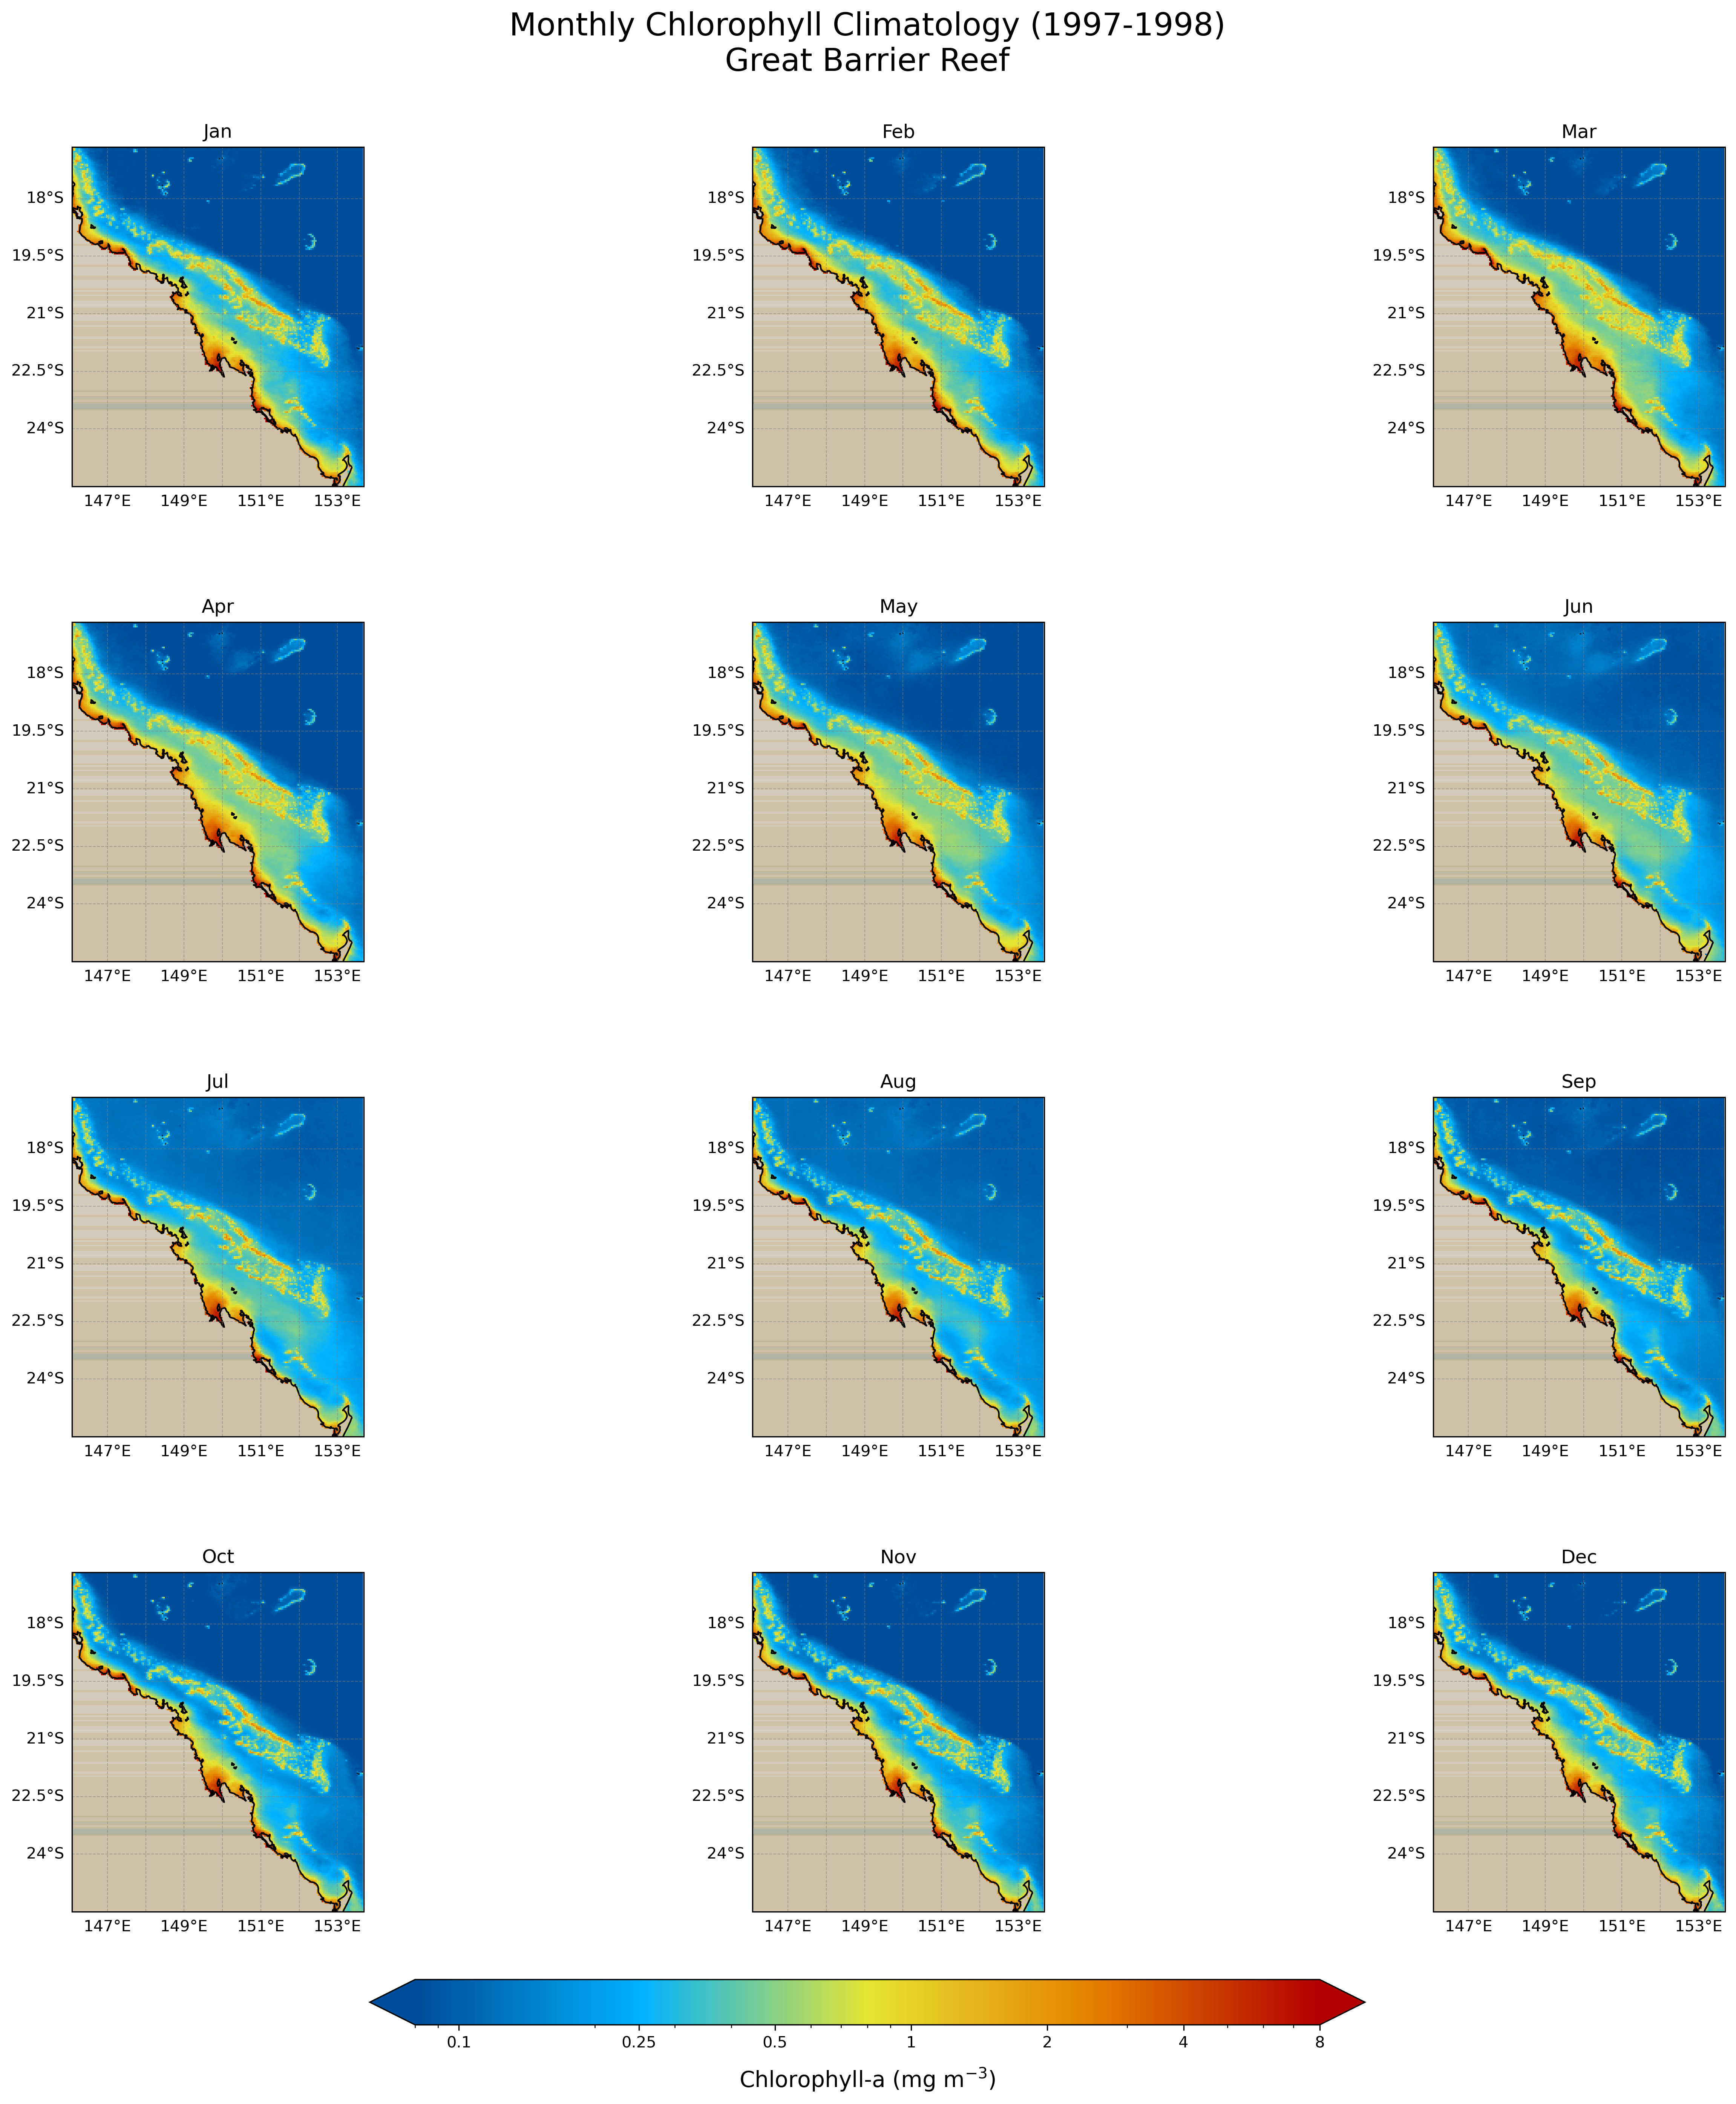

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import matplotlib as mpl
from calendar import month_abbr

bathy = xr.open_dataset(r"C:/Users/jjmcl/OneDrive/Desktop/GMRTv4_3_0_20250329topo.grd")
chlor = xr.open_dataset(r"C:/Users/jjmcl/OneDrive/Desktop/P4/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

print("Chlorophyll time range:", chlor.time.min().values, "to", chlor.time.max().values)
print("Available months:", np.unique(chlor.time.dt.month.values))

if chlor['lon'].max() > 180:
    chlor = chlor.assign_coords(lon=(((chlor['lon'] + 180) % 360) - 180))
chlor = chlor.sortby('lat')

true_lat, true_lon = int(bathy['dimension'][0]), int(bathy['dimension'][1])
lat_bathy = np.linspace(float(bathy['y_range'][0]), float(bathy['y_range'][1]), true_lat)
lon_bathy = np.linspace(float(bathy['x_range'][0]), float(bathy['x_range'][1]), true_lon)
z_bathy = bathy['z'].values.reshape((true_lat, true_lon))

buffer = 2.0
x_min, x_max = float(bathy['x_range'][0]), float(bathy['x_range'][1])
y_min, y_max = float(bathy['y_range'][0]), float(bathy['y_range'][1])
chlor_subset = chlor.sel(
    lat=slice(y_min-buffer, y_max+buffer),
    lon=slice(x_min-buffer, x_max+buffer)
)

chl_colors = [(0, 0.3, 0.6), (0, 0.7, 1), (0.9, 0.9, 0.2), (0.9, 0.5, 0), (0.7, 0, 0)]
chl_cmap = mpl.colors.LinearSegmentedColormap.from_list('chl_cmap', chl_colors, N=256)
bathy_cmap = cmocean.cm.topo

fig = plt.figure(figsize=(22, 20), dpi=300)  # Increased height for colorbar
actual_years = f"{chlor.time.dt.year.min().values}-{chlor.time.dt.year.max().values}"
fig.suptitle(f"Monthly Chlorophyll Climatology ({actual_years})\nGreat Barrier Reef", 
             fontsize=20, y=0.94)

grid = plt.GridSpec(4, 3, hspace=0.4, wspace=0.2, bottom=0.1)

for i, month in enumerate(range(1, 13)):
    ax = fig.add_subplot(grid[i//3, i%3], projection=ccrs.PlateCarree())
    
   
    monthly_data = chlor_subset['chlor_a'].sel(
        time=chlor_subset['time.month'] == month
    ).mean(dim='time')
    
   
    monthly_data = monthly_data.where(np.isfinite(monthly_data))
    
   
    xx, yy = np.meshgrid(chlor_subset.lon, chlor_subset.lat)
    bathy_interp = np.interp(yy.ravel(), lat_bathy, z_bathy[:,0])
    bathy_interp = bathy_interp.reshape(xx.shape)
    
    ax.contourf(
        chlor_subset.lon,
        chlor_subset.lat,
        bathy_interp,
        levels=np.linspace(-6000, 1000, 15),
        cmap=bathy_cmap,
        alpha=0.3,
        transform=ccrs.PlateCarree()
    )
    
    chlor_plot = ax.pcolormesh(
        chlor_subset.lon,
        chlor_subset.lat,
        monthly_data,
        cmap=chl_cmap,
        norm=LogNorm(vmin=0.08, vmax=8),
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.set_title(f"{month_abbr[month]}", fontsize=12)
    ax.set_extent([x_min-buffer, x_max+buffer, y_min-buffer, y_max+buffer], crs=ccrs.PlateCarree())
    
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                     linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])  
cbar = fig.colorbar(chlor_plot, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_ticks([0.1, 0.25, 0.5, 1, 2, 4, 8])
cbar.set_ticklabels(['0.1', '0.25', '0.5', '1', '2', '4', '8'])
cbar.set_label('Chlorophyll-a (mg m$^{-3}$)', fontsize=14, labelpad=10)

# Save plot and display
plt.savefig('GBR_Chlorophyll_Climatology.png', dpi=300, bbox_inches='tight')
plt.show()

### The last plot produced is a timeseries meant to highlight differences between the average chlorophyll concentration produced annually in comparison to the average chlorophyll concentration of a single point in the region. This plot highlights how the averaging across all points creates a 'smoother' plot which may indicate less variations across the dataset whereas the plot produced for a single plot is not as more smooth and is more 'angular' which could indicate that the variations between months across seasons is more stark and abrupt than averages across the whole Great Barrier Reef region.

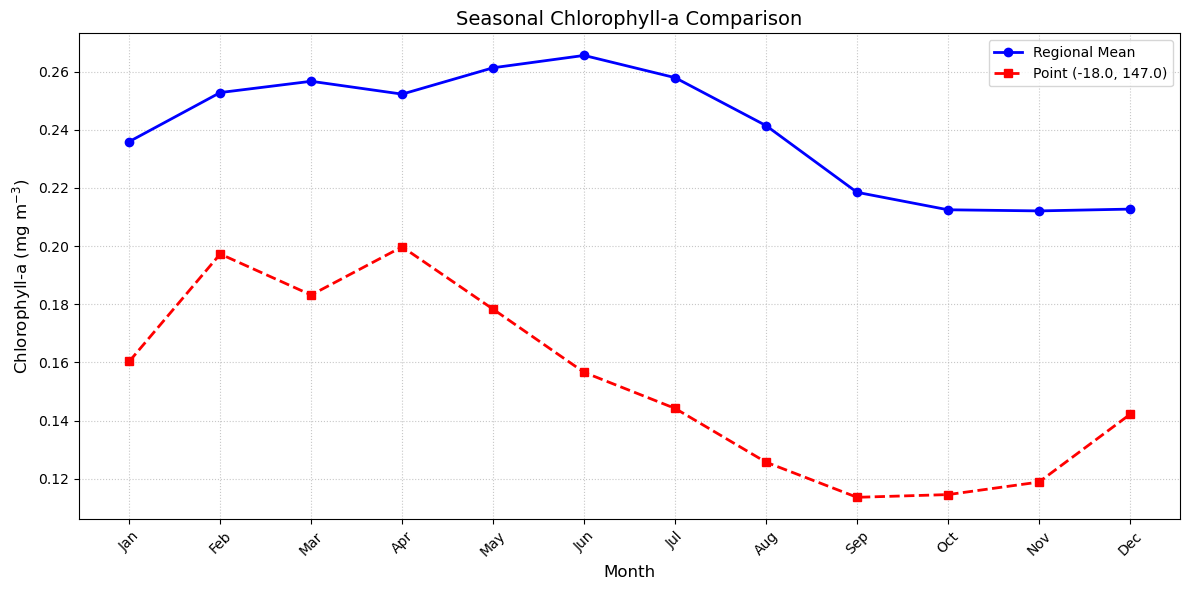

In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

chlor = xr.open_dataset(r"C:/Users/jjmcl/OneDrive/Desktop/P4/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

if chlor['lon'].max() > 180:
    chlor = chlor.assign_coords(lon=(((chlor['lon'] + 180) % 360) - 180))
chlor = chlor.sortby('lat')

region = chlor.sel(
    lat=slice(-25, -10),  # Adjust these values for your specific region
    lon=slice(140, 160)
)

# 3. Calculate the mean seasonal cycle for the whole region
mean_seasonal_cycle = region['chlor_a'].groupby('time.month').mean(dim=['time', 'lat', 'lon'])

# 4. Choose a point close to high chlorophyll area
lat_point, lon_point = -18.0, 147.0  # Example coordinates near coast
point_data = region['chlor_a'].sel(
    lat=lat_point,
    lon=lon_point,
    method='nearest'
)

# 5. Calculate monthly means for the point
point_seasonal = point_data.groupby('time.month').mean(dim='time')

# 6. Plot the comparison
plt.figure(figsize=(12, 6))

plt.plot(
    mean_seasonal_cycle['month'], 
    mean_seasonal_cycle, 
    label='Regional Mean', 
    color='blue', 
    linewidth=2,
    marker='o'
)

plt.plot(
    point_seasonal['month'], 
    point_seasonal, 
    label=f'Point ({lat_point}, {lon_point})', 
    color='red', 
    linewidth=2,
    linestyle='--',
    marker='s'
)

plt.title('Seasonal Chlorophyll-a Comparison', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Chlorophyll-a (mg m$^{-3}$)', fontsize=12)
plt.xticks(
    ticks=np.arange(1, 13),
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

## References
### Brodie, J., De’Ath, G., Devlin, M., Furnas, M. and Wright, M., 2007. Spatial and temporal patterns of near-surface chlorophyll a in the Great Barrier Reef lagoon. Marine and Freshwater Research, 58(4), pp.342-353.
### Furnas, M., Mitchell, A., Skuza, M. and Brodie, J., 2005. In the other 90%: phytoplankton responses to enhanced nutrient availability in the Great Barrier Reef Lagoon. Marine pollution bulletin, 51(1-4), pp.253-265.
### Sathyendranath, S, Brewin, RJW, Brockmann, C, Brotas, V, Calton, B, Chuprin, A, Cipollini, P, Couto, AB, Dingle, J, Doerffer, R, Donlon, C, Dowell, M, Farman, A, Grant, M, Groom, S, Horseman, A, Jackson, T, Krasemann, H, Lavender, S, Martinez-Vicente, V, Mazeran, C, Mélin, F, Moore, TS, Müller, D, Regner, P, Roy, S, Steele, CJ, Steinmetz, F, Swinton, J, Taberner, M, Thompson, A, Valente, A, Zühlke, M, Brando, VE, Feng, H, Feldman, G, Franz, BA, Frouin, R, Gould, Jr., RW, Hooker, SB, Kahru, M, Kratzer, S, Mitchell, BG, Muller-Karger, F, Sosik, HM, Voss, KJ, Werdell, J, and Platt, T (2019) An ocean-colour time series for use in climate studies: the experience of the Ocean-Colour Climate Change Initiative (OC-CCI). Sensors: 19, 4285. doi:10.3390/s19194285
### Ryan, W.B.F., S.M. Carbotte, J.O. Coplan, S. O'Hara, A. Melkonian, R. Arko, R.A. Weissel, V. Ferrini, A. Goodwillie, F. Nitsche, J. Bonczkowski, and R. Zemsky (2009), Global Multi-Resolution Topography synthesis, Geochem. Geophys. Geosyst., 10, Q03014, doi: 10.1029/2008GC002332